In [1]:
# Cell 1 — Imports
import os
os.chdir(r'C:\Users\PC\financial-news-sentiment')

import pandas as pd
import numpy as np
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Cell 2 — Load preprocessed data
X_train_tfidf, X_test_tfidf, y_train, y_test = joblib.load('models/train_test_split.pkl')

print(f"Train shape: {X_train_tfidf.shape}")
print(f"Test shape: {X_test_tfidf.shape}")
print(f"\nLabel distribution in train:\n{y_train.value_counts()}")

Train shape: (3934, 5000)
Test shape: (984, 5000)

Label distribution in train:
sentiment_label
neutral     2337
positive    1100
negative     497
Name: count, dtype: int64


In [3]:
# Cell 3 — Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print(f"Classes: {le.classes_}")
print(f"Encoded as: {list(range(len(le.classes_)))}")

Classes: ['negative' 'neutral' 'positive']
Encoded as: [0, 1, 2]


In [4]:
# Cell 4 — Baseline: Logistic Regression with class weights
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_tfidf, y_train_enc)

y_pred_lr = lr.predict(X_test_tfidf)
y_prob_lr = lr.predict_proba(X_test_tfidf)

print("=== Logistic Regression ===")
print(classification_report(y_test_enc, y_pred_lr, target_names=le.classes_))
print(f"Macro ROC-AUC: {roc_auc_score(y_test_enc, y_prob_lr, multi_class='ovr', average='macro'):.3f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

    negative       0.62      0.73      0.67       124
     neutral       0.83      0.80      0.82       585
    positive       0.67      0.67      0.67       275

    accuracy                           0.76       984
   macro avg       0.71      0.73      0.72       984
weighted avg       0.76      0.76      0.76       984

Macro ROC-AUC: 0.883


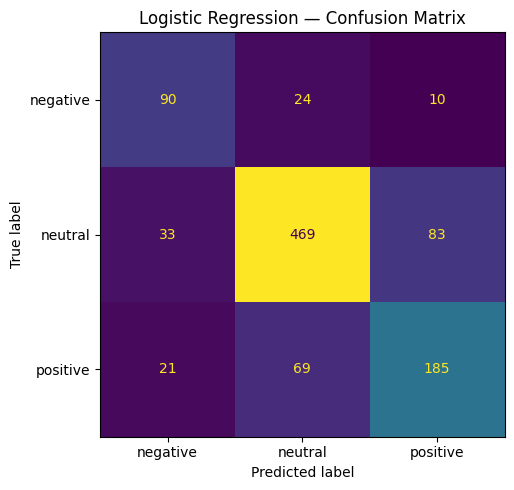

In [5]:
# Cell 5 — Confusion matrix: Logistic Regression
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_enc, y_pred_lr,
    display_labels=le.classes_,
    ax=ax,
    colorbar=False
)
plt.title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.savefig('reports/confusion_matrix_lr.png', dpi=150)
plt.show()

In [6]:
# Cell 6 — XGBoost with class weights
scale_pos = len(y_train_enc) / (len(le.classes_) * np.bincount(y_train_enc))
sample_weights = np.array([scale_pos[label] for label in y_train_enc])

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
xgb.fit(X_train_tfidf, y_train_enc, sample_weight=sample_weights)

y_pred_xgb = xgb.predict(X_test_tfidf)
y_prob_xgb = xgb.predict_proba(X_test_tfidf)

print("=== XGBoost ===")
print(classification_report(y_test_enc, y_pred_xgb, target_names=le.classes_))
print(f"Macro ROC-AUC: {roc_auc_score(y_test_enc, y_prob_xgb, multi_class='ovr', average='macro'):.3f}")

=== XGBoost ===
              precision    recall  f1-score   support

    negative       0.66      0.69      0.67       124
     neutral       0.81      0.86      0.84       585
    positive       0.72      0.61      0.66       275

    accuracy                           0.77       984
   macro avg       0.73      0.72      0.73       984
weighted avg       0.77      0.77      0.77       984

Macro ROC-AUC: 0.883


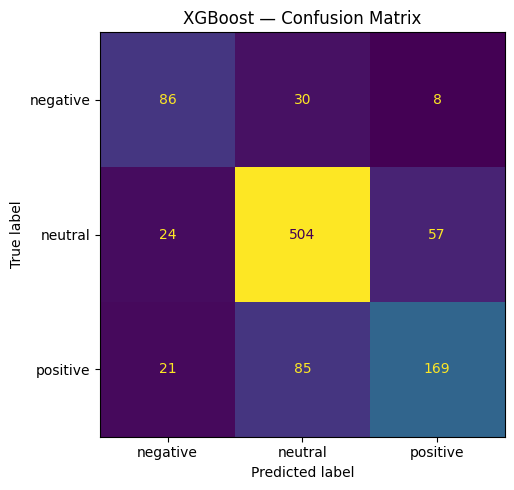

In [7]:
# Cell 7 — Confusion matrix: XGBoost
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_enc, y_pred_xgb,
    display_labels=le.classes_,
    ax=ax,
    colorbar=False
)
plt.title("XGBoost — Confusion Matrix")
plt.tight_layout()
plt.savefig('reports/confusion_matrix_xgb.png', dpi=150)
plt.show()

In [8]:
# Cell 8 — Model comparison summary
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'Negative Recall': [
        classification_report(y_test_enc, y_pred_lr, output_dict=True)['0']['recall'],
        classification_report(y_test_enc, y_pred_xgb, output_dict=True)['0']['recall']
    ],
    'Macro F1': [
        classification_report(y_test_enc, y_pred_lr, output_dict=True)['macro avg']['f1-score'],
        classification_report(y_test_enc, y_pred_xgb, output_dict=True)['macro avg']['f1-score']
    ],
    'Macro ROC-AUC': [
        roc_auc_score(y_test_enc, y_prob_lr, multi_class='ovr', average='macro'),
        roc_auc_score(y_test_enc, y_prob_xgb, multi_class='ovr', average='macro')
    ]
}).round(3)

print(results.to_string(index=False))

              Model  Negative Recall  Macro F1  Macro ROC-AUC
Logistic Regression            0.726     0.720          0.883
            XGBoost            0.694     0.725          0.883


In [9]:
# Cell 9 — Save models
joblib.dump(lr, 'models/logistic_regression.pkl')
joblib.dump(xgb, 'models/xgboost_model.pkl')
joblib.dump(le, 'models/label_encoder.pkl')
print("Models saved.")

Models saved.
